In [1]:
# Standard Data Science Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
import pyarrow

# Tiingo API
import tiingo
from tiingo import TiingoClient

# Web Requests and Querying
import requests
import  json
import os
#import pandas_datareader as web
#from aquarel import load_theme

from dotenv import load_dotenv
load_dotenv()  # Load environment variables from .env file

True

In [2]:
# Initialize Tiingo Client
config = {
    'session': True,
    'api_key': os.getenv("TIINGO_API_KEY")
}

client = TiingoClient(config)

In [3]:
# Tiingo's list of stock tickers
tickers = client.list_stock_tickers()

In [4]:
# Fetch historical price data for SPY

if os.path.exists('data/spy_daily.parquet'):
    spy_weekly_df = pd.read_parquet('data/spy_daily.parquet', index='date')
else:
    spy_weekly = client.get_ticker_price("SPY", 
                                         frequency="daily", 
                                         columns='open,low,high,adjClose,volume',
                                         startDate='2015-01-01',
                                     endDate='2025-12-31')

In [5]:
# Convert to DataFrame and set date as index
spy_weekly_df = pd.DataFrame(spy_weekly)

spy_weekly_df['date'] = pd.to_datetime(spy_weekly_df['date'])
spy_weekly_df.set_index('date', inplace=True)

spy_weekly_df.to_parquet('./data/spy_daily.parquet', index=True)

In [6]:
# Calculate returns
    # Percentage returns
spy_weekly_df['ret'] = spy_weekly_df['adjClose'].pct_change()
    # Absolute returns
spy_weekly_df['usd_ret'] = spy_weekly_df['adjClose'].diff()

# Drop NA values
spy_weekly_df.dropna(inplace=True)

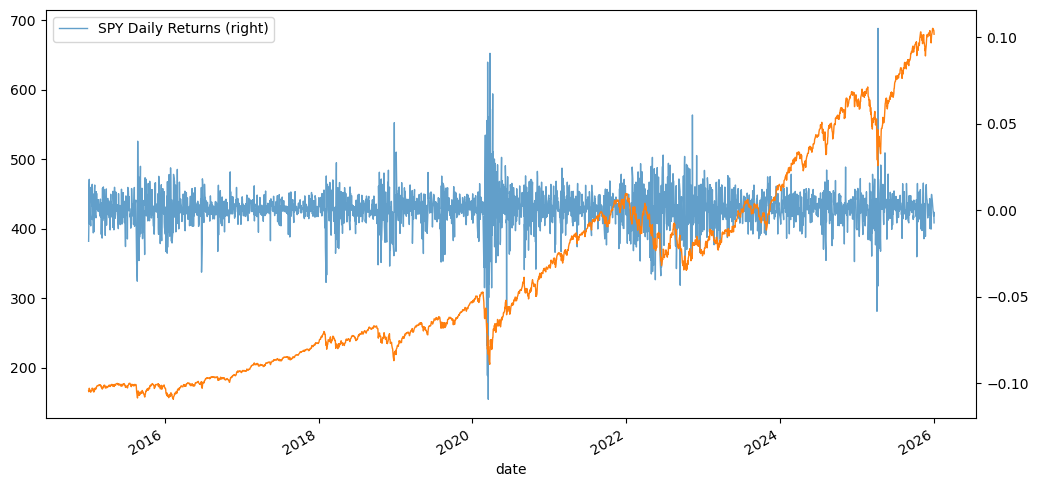

In [7]:
# Plotting the adjusted close prices and returns

fig, ax = plt.subplots(figsize=(12, 6))
ax2 = spy_weekly_df['ret'].plot(ax=ax, label='SPY Daily Returns', secondary_y=True, linewidth=1, alpha=0.7)
spy_weekly_df['adjClose'].plot(ax=ax, label='SPY Daily Closing Prices', linewidth=1)
#spy_weekly_df['usd_ret'].plot(ax=ax, label='SPY Daily Absolute Returns')

ax.set_zorder(ax2.get_zorder()+1)
ax.set_frame_on(False)

plt.legend()
plt.show()

<Axes: title={'center': 'SPY Weekly Returns vs Adjusted Closing Prices'}, xlabel='adjClose', ylabel='ret'>

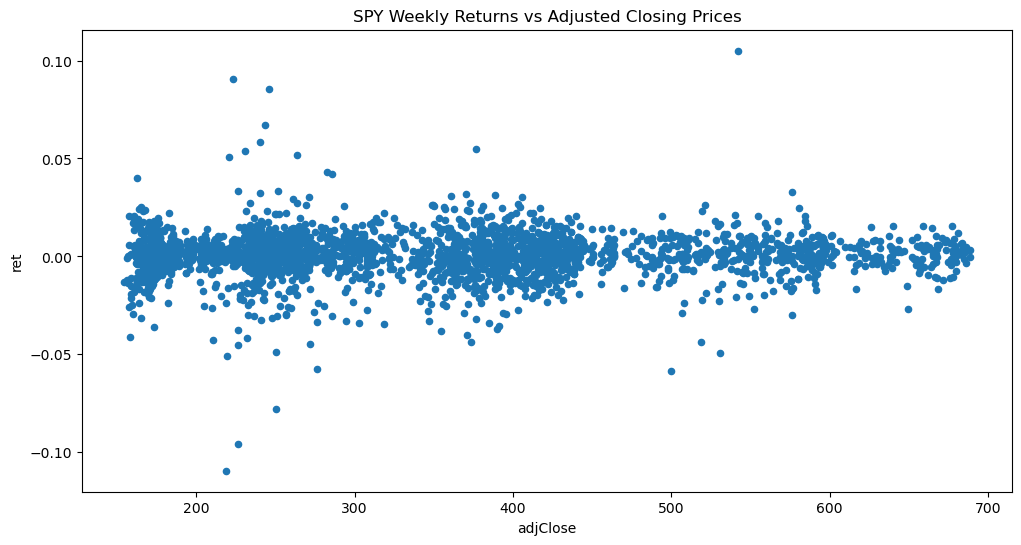

In [8]:
# Scatter plot of returns vs adjusted close prices
fig, ax = plt.subplots(figsize=(12, 6))
spy_weekly_df.plot(x='adjClose',y='ret', kind='scatter', ax=ax, title='SPY Weekly Returns vs Adjusted Closing Prices')

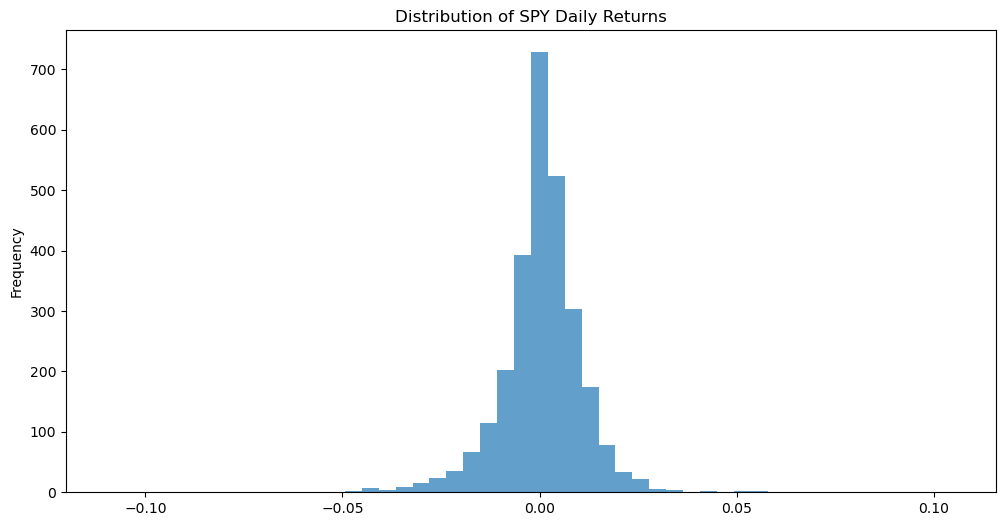

In [9]:
# Distribution plot of returns and binned closing price
fig, ax = plt.subplots(figsize=(12, 6))
spy_weekly_df['ret'].plot(kind='hist', bins=50, alpha=0.7, ax=ax, title='Distribution of SPY Daily Returns')
plt.show()

# GKX Model,Python Implementation (Scikit-Learn)

**OLS**,sklearn.linear_model.LinearRegression

**PLS** (Partial Least Squares),sklearn.cross_decomposition.PLSRegression

**PCR** (Principal Comp Reg),sklearn.decomposition.PCA + LinearRegression

**Elastic Net**,sklearn.linear_model.ElasticNet

**RF** (Random Forest),sklearn.ensemble.RandomForestRegressor

**NN1 - NN5** (Neural Nets),sklearn.neural_network.MLPRegressor (Easiest) or PyTorch (Best)


In [10]:
from sklearn import linear_model, cross_decomposition, decomposition, ensemble, neural_network

In [11]:
reg = linear_model.LinearRegression()
X = spy_weekly_df[['volume']]
y = spy_weekly_df['ret']

In [12]:
import pandas_datareader as pdr
from datetime import datetime
import tiingo
from tiingo import TiingoClient

# Set your date range
start = datetime(2020, 1, 1)
end = datetime(2026, 1, 1)

# Pull the data using the FRED series ID (e.g., 'GDP', 'UNRATE', 'EFFR')
df = pdr.get_data_fred('GDP', start, end)

# Save to share with students
df.to_csv('fred_data.csv')
print("Data downloaded successfully!")



# Initialize Tiingo Client
config = {
    'session': True,
    'api_key': os.getenv("TIINGO_API_KEY")
}

client = TiingoClient(config)

TypeError: deprecate_kwarg() missing 1 required positional argument: 'new_arg_name'

In [ ]:
import os
import requests
import pandas as pd
import io

# ==========================================
# 1. SETUP & CONFIGURATION
# ==========================================
# Ensure your Tiingo key is set, either here or exported in the terminal
tiingo_key = os.getenv('TIINGO_API_KEY', 'YOUR_TIINGO_API_KEY_HERE')
start_date = '2020-01-01'

# FRED Tickers (Monthly and Daily)
fred_tickers = ['CPIAUCSL', 'DGS10', 'FEDFUNDS', 'VIXCLS', 'UNRATE']
# Tiingo Tickers (Technology, Financials, Industrials ETFs)
tiingo_tickers = ['XLK', 'XLF', 'XLI']

# ==========================================
# 2. FETCH FRED DATA (Direct CSV via Requests)
# ==========================================
print("Fetching FRED data...")
fred_dfs = []
# Spoof a standard browser to bypass FRED's bot blocking
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}

for ticker in fred_tickers:
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={ticker}"
    response = requests.get(url, headers=headers)
    
    if response.status_code == 200:
        # Wrap the raw text in StringIO so pandas can read it like a file
        df = pd.read_csv(io.StringIO(response.text), index_col='DATE', parse_dates=True, na_values=['.'])
        df.index.name = 'date'
        fred_dfs.append(df.loc[start_date:])
    else:
        print(f"Failed to fetch {ticker} from FRED. Status Code: {response.status_code}")

# Combine all FRED series into one dataframe
fred_df = pd.concat(fred_dfs, axis=1) if fred_dfs else pd.DataFrame()

# ==========================================
# 3. FETCH TIINGO DATA (REST API)
# ==========================================
print("Fetching Tiingo data...")
tiingo_dfs = []
headers = {'Content-Type': 'application/json'}

for ticker in tiingo_tickers:
    url = f"https://api.tiingo.com/tiingo/daily/{ticker}/prices?startDate={start_date}&token={tiingo_key}"
    response = requests.get(url, headers=headers)
    
    if response.status_code == 200:
        data = response.json()
        if isinstance(data, list) and len(data) > 0:
            df = pd.DataFrame(data)
            # Remove the timezone information so it aligns with FRED dates
            df['date'] = pd.to_datetime(df['date']).dt.tz_localize(None)
            df.set_index('date', inplace=True)
            # Isolate the adjusted close price and rename the column to the ticker symbol
            df = df[['adjClose']].rename(columns={'adjClose': ticker})
            tiingo_dfs.append(df)
    else:
        print(f"Failed to fetch {ticker} from Tiingo: {response.text}")

# Combine all Tiingo series, or create an empty dataframe if it failed
tiingo_df = pd.concat(tiingo_dfs, axis=1) if tiingo_dfs else pd.DataFrame()

# ==========================================
# 4. CLEAN & MERGE
# ==========================================
print("Merging datasets and standardizing frequency...")
merged_df = fred_df.join(tiingo_df, how='outer') if not tiingo_df.empty else fred_df

# Forward-fill (ffill) missing daily data (like weekend ETF prices) 
# so the month-end resample always captures the final trading day of the month
merged_df.ffill(inplace=True)

# Resample to Month-End ('ME') frequency
monthly_df = merged_df.resample('ME').last()

# ==========================================
# 5. EXPORT
# ==========================================
output_filename = 'macro_and_sector_data.csv'
monthly_df.to_csv(output_filename)
print(f"Success! Data exported to {output_filename} in the current directory.")